In [1]:
import xarray as xr
import os   
import parflow as pf
import plotly.express as px
from parflow.tools.hydrology import calculate_overland_flow_grid, calculate_subsurface_storage, calculate_water_table_depth
import numpy as np
import shutil
import json
import plotly.io as pio
import matplotlib.pyplot as mpl

In [2]:
root_dir = "/glade/derecho/scratch/bwest/drought-ensemble"
domain = "wolf"
ensemble_name = "ensemble_1"
ensemble_member = "8_year_drought"
files = json.load(open(f"{root_dir}/domains/{domain}/processed_full_runs/{ensemble_name}/{ensemble_member}/file_locations.json"))
data = xr.open_mfdataset(files, concat_dim="time", combine="nested")
data.info()

/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/bwest/conda-envs/droughts/share/proj failed
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: 

xarray.Dataset {
dimensions:
	time = 140160 ;
	z = 10 ;
	y = 41 ;
	x = 78 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 subsurface_storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

In [3]:
ensemble_member = "baseline"
baseline_files = json.load(open(f"{root_dir}/domains/{domain}/processed_full_runs/{ensemble_name}/{ensemble_member}/file_locations.json"))
baseline_data = xr.open_mfdataset(baseline_files, concat_dim="time", combine="nested")
baseline_data.info()

/glade/derecho/scratch/bwest/tmp/ipykernel_56035/3719063120.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  baseline_data = xr.open_mfdataset(baseline_files, concat_dim="time", combine="nested")


xarray.Dataset {
dimensions:
	time = 140160 ;
	z = 10 ;
	y = 41 ;
	x = 78 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 subsurface_storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

Text(0.5, 1.0, '')

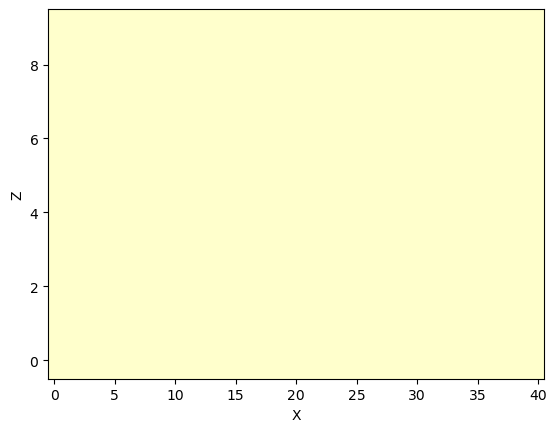

In [4]:
pre_drought_storage = data.isel(time=8760*2).subsurface_storage.sum(dim="x")
pre_drought_storage_baseline = baseline_data.isel(time=8760*2).subsurface_storage.sum(dim="x")

ratio = (pre_drought_storage / pre_drought_storage_baseline)
ax = ratio.plot(
    vmin=0,
    vmax=1,
    cmap="YlOrRd_r",
    add_colorbar=False,
)
# ax.colorbar.set_label("Fraction of storage relative to baseline")  # Remove label from colorbar
ax.axes.set_xlabel("X")
ax.axes.set_ylabel("Z")
ax.axes.set_title("")

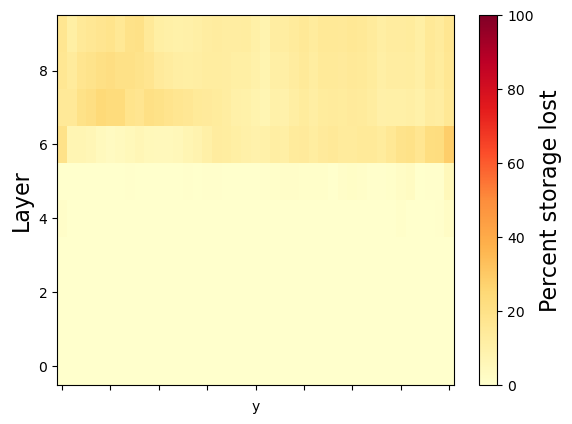

In [19]:
layer_thickness = [1.0, 0.5, 0.25, 0.125, 0.05, 0.025, 0.005, 0.003, 0.0015, 0.0005]

post_drought_storage = data.isel(time=int(8760*7)).subsurface_storage.sum(dim="x")
post_drought_storage_baseline = baseline_data.isel(time=int(8760*7)).subsurface_storage.sum(dim="x")

ratio = (post_drought_storage / post_drought_storage_baseline)
ratio = (1.0-ratio)*100
ax = ratio.plot(
    vmin=0,
    vmax=100,
    cmap="YlOrRd",
    add_colorbar=True,
)
ax.colorbar.set_label("Percent storage lost")  # Remove label from colorbar
# ax.axes.set_xlabel("X")
ax.axes.set_xticklabels([])
ax.axes.set_ylabel("Layer")
ax.axes.set_title("", fontsize=16)
ax.axes.set_ylabel("Layer", fontsize=16)
ax.colorbar.set_label("Percent storage lost", fontsize=16)

Text(0.5, 1.0, '')

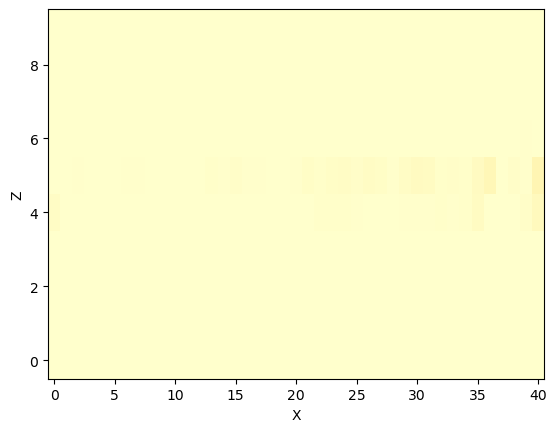

In [ ]:
end_drought_storage = data.isel(time=int(8760*12)).subsurface_storage.sum(dim="x")
end_drought_storage_baseline = baseline_data.isel(time=int(8760*12)).subsurface_storage.sum(dim="x")

ratio = (end_drought_storage / end_drought_storage_baseline)
ax = ratio.plot(
    vmin=0,
    vmax=1,
    cmap="YlOrRd_r",
    add_colorbar=False,
)
# ax.colorbar.set_label("Fraction of storage relative to baseline")  # Remove label from colorbar
ax.axes.set_xlabel("X")
ax.axes.set_ylabel("Z")
ax.axes.set_title("")


In [ ]:
total_drought_deficit = (post_drought_storage_baseline - post_drought_storage).sum()
float(total_drought_deficit)

157707753.65411553

In [ ]:
ensemble_name = "pumping_ensemble"
ensemble_member = "pumping_0_01"
files = json.load(open(f"{root_dir}/domains/{domain}/processed_full_runs/{ensemble_name}/{ensemble_member}/file_locations.json"))
pumping_data = xr.open_mfdataset(files, concat_dim="time", combine="nested")
pumping_data.info()

/glade/derecho/scratch/bwest/tmp/ipykernel_95141/1919025666.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  pumping_data = xr.open_mfdataset(files, concat_dim="time", combine="nested")


xarray.Dataset {
dimensions:
	time = 157680 ;
	z = 10 ;
	y = 41 ;
	x = 78 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 subsurface_storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

In [ ]:
ensemble_name = "pumping_ensemble"
ensemble_member = "baseline"
files = json.load(open(f"{root_dir}/domains/{domain}/processed_full_runs/{ensemble_name}/{ensemble_member}/file_locations.json"))
baseline_pumping_data = xr.open_mfdataset(files, concat_dim="time", combine="nested")
baseline_pumping_data.info()

/glade/derecho/scratch/bwest/tmp/ipykernel_95141/1241237330.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  baseline_pumping_data = xr.open_mfdataset(files, concat_dim="time", combine="nested")


xarray.Dataset {
dimensions:
	time = 157680 ;
	z = 10 ;
	y = 41 ;
	x = 78 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 subsurface_storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

Text(0.5, 1.0, '')

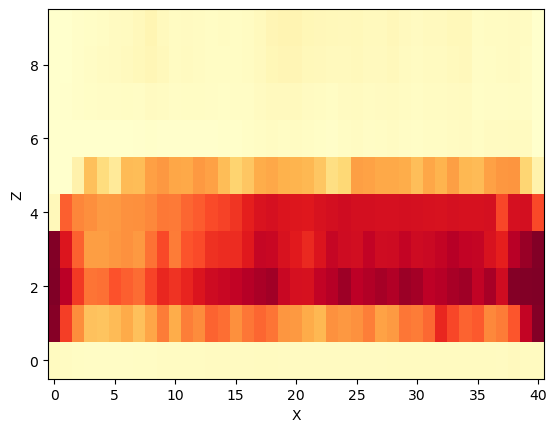

In [ ]:
post_pumping_storage = pumping_data.isel(time=int(8760*8)).subsurface_storage.sum(dim="x")
post_pumping_storage_baseline = baseline_pumping_data.isel(time=int(8760*8)).subsurface_storage.sum(dim="x")

post_pumping_storage = data.isel(time=int(8760*7)).subsurface_storage.sum(dim="x")
post_pumping_storage_baseline = baseline_data.isel(time=int(8760*7)).subsurface_storage.sum(dim="x")

ratio = (post_pumping_storage / post_pumping_storage_baseline)
ratio = (1.0-ratio)*100
ax = ratio.plot(
    vmin=0,
    vmax=100,
    cmap="YlOrRd",
    add_colorbar=True,
)
ax.colorbar.set_label("Percent storage lost")  # Remove label from colorbar
# ax.axes.set_xlabel("X")
ax.axes.set_xticklabels([])
ax.axes.set_ylabel("Layer")
ax.axes.set_title("", fontsize=16)
ax.axes.set_ylabel("Layer", fontsize=16)
ax.colorbar.set_label("Percent storage lost", fontsize=16)



Text(0.5, 1.0, '')

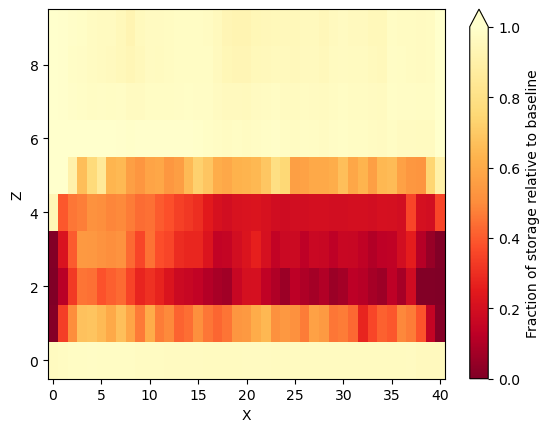

In [ ]:
post_pumping_storage = pumping_data.isel(time=int(8760*9)).subsurface_storage.sum(dim="x")
post_pumping_storage_baseline = baseline_pumping_data.isel(time=int(8760*9)).subsurface_storage.sum(dim="x")

ratio = post_pumping_storage / post_pumping_storage_baseline
ax = ratio.plot(
    vmin=0,
    vmax=1,
    cmap="YlOrRd_r",
    add_colorbar=True,
)
ax.colorbar.set_label("Fraction of storage relative to baseline")  
ax.axes.set_xlabel("X")
ax.axes.set_ylabel("Z")
ax.axes.set_title("")

In [ ]:
total_pumping_deficit = (post_pumping_storage_baseline - post_pumping_storage).sum()
float(total_pumping_deficit)



61400208903.300606

In [ ]:
data.info()

xarray.Dataset {
dimensions:
	time = 140160 ;
	z = 10 ;
	y = 41 ;
	x = 78 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 subsurface_storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

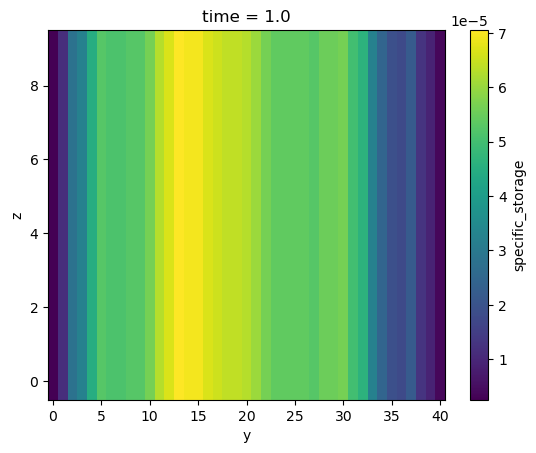

In [ ]:
data.isel(time=0).specific_storage.mean(dim="x").plot()

In [ ]:
wolf_flow_barrier = pf.read_pfb("/glade/derecho/scratch/bwest/drought-ensemble/domains/wolf/raw_runs/0c848a509f6a1448e4a9f6660f12ef4ea4057f51b98f08a0c8315acf3baa8a01/pf_flowbarrier.pfb")

In [ ]:
from plotly import graph_objects as go
# set plotly template to plotly_white
pio.templates.default = "plotly_white"
# plot the flow barrier in plotly express and show gridlines

fig = go.Figure(data=go.Heatmap(z=wolf_flow_barrier[:,20,:]))
fig.update_layout(
    title='Wolf Flow Barrier',
    xaxis_title='X',
    yaxis_title='Y',
    width=600,
    height=600,
)





In [ ]:
potomac_flow_barrier = pf.read_pfb("/glade/derecho/scratch/bwest/drought-ensemble/domains/potomac_save/raw_runs/0c848a509f6a1448e4a9f6660f12ef4ea4057f51b98f08a0c8315acf3baa8a01/pf_flowbarrier.pfb")
mpl.imshow(potomac_flow_barrier[:,20,:])

FileNotFoundError: [Errno 2] No such file or directory: '/glade/derecho/scratch/bwest/drought-ensemble/domains/potomac_save/raw_runs/0c848a509f6a1448e4a9f6660f12ef4ea4057f51b98f08a0c8315acf3baa8a01/pf_flowbarrier.pfb'